In [1]:
%load_ext autoreload
%autoreload 2
from eda_package import *
import json

/home/alexbeecken/.pyenv/versions/noshowshield/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
row_to_api_json(5)

NameError: name 'row_to_api_json' is not defined

In [ ]:
df = load_raw_data()
df = clean_data(df)
df = group_countries(df, COUNTRY_LIMIT)
df = engineer_features(df)
#training_set, test_set = temporal_split_v2(df, 2017, 5)
training_set, test_set = temporal_split(df, 2017)

X_train, y_train= split_X_y(training_set)
X_test, y_test= split_X_y(test_set)

X_train_processed, X_test_processed = preprocess_pipeline(X_train, X_test)

In [ ]:
model = BookingPredictor(X_train_processed=X_train_processed, y_train=y_train)
model.test(X_test_processed, y_test)
model.save_model()

In [ ]:
model

In [ ]:
model = BookingPredictor()

In [ ]:
model.test(X_test_processed, y_test)

In [ ]:
from eda_package.main import load_and_preprocess


X_train_processed, X_test_processed, y_train, y_test = load_and_preprocess()

X_train_processed

In [ ]:
from eda_package.main import pred

import pandas as pd
import numpy as np
from eda_package.main import pred

X_pred = pd.DataFrame([{
    "hotel": "City Hotel",
    "lead_time": 112,
    "arrival_date_year": 2016,
    "arrival_date_month": "December",
    "arrival_date_week_number": 53,
    "arrival_date_day_of_month": 27,
    "stays_in_weekend_nights": 0,
    "stays_in_week_nights": 3,
    "adults": 3,
    "children": 0.0,
    "babies": 0,
    "meal": "BB",
    "country": "PRT",
    "market_segment": "Online TA",
    "distribution_channel": "TA/TO",
    "is_repeated_guest": 0,
    "previous_cancellations": 0,
    "previous_bookings_not_canceled": 0,
    "reserved_room_type": "D",
    "assigned_room_type": "D",
    "booking_changes": 0,
    "deposit_type": "No Deposit",
    "agent": 83.0,
    "company": np.nan,
    "days_in_waiting_list": 0,
    "customer_type": "Transient",
    "adr": 131.13,
    "required_car_parking_spaces": 0,
    "total_of_special_requests": 0
}])

pred(X_pred)

In [ ]:
def optimise(
    relocation_cost: float,
    max_risk: float
)-> dict:

    user_input = {
        "relocation_cost": relocation_cost,
        "max_risk": max_risk,
        "max_extra_sweep": 500,
        "model_file_name": WORKING_MODEL_FILE_NAME,
        "preprocessor_file_name": "preprocessor.joblib",
    }

    return run_from_saved_model(**user_input)

In [ ]:
from eda_package import *


In [ ]:
optimise(relocation_cost=100, max_risk=0.05)

In [ ]:
run_from_saved_model(
    relocation_cost = 300.0,
    max_risk = 0.02,
    max_extra_sweep = 300,
    model_file_name = WORKING_MODEL_FILE_NAME,
    preprocessor_file_name = "preprocessor.joblib",
)

In [ ]:
    from eda_package.registry import *
    from eda_package.data import DataManager

    data_manager = DataManager()
    df = data_manager.prepare_dataset()
    X_train, X_test, y_train, y_test = data_manager.prepare_train_test_data()

In [ ]:
from eda_package.preprocessor import PreprocessorManager

preprocessor_manager = PreprocessorManager()

# Training
X_train_processed, X_test_processed, preprocessor = (
    preprocessor_manager.prepare_train_test(X_train, X_test)
)
preprocessor_manager.save()

In [ ]:
from eda_package.model import ModelManager

model_manager = ModelManager()

# Training
model_manager.train(X_train_processed, y_train)
metrics = model_manager.evaluate(X_test_processed, y_test)
model_manager.save()

In [ ]:
# from eda_package.explainer import SHAPExplainer
# explainer = SHAPExplainer.from_working_model()
# global_imp = explainer.global_feature_importance(X_test, top_n=20)
# local_df = explainer.local_explanation(X_test, index=0)
# api_payload = explainer.format_explanation_for_api(global_imp)

In [3]:
!pip install shap
import shap
# Run the following command. Needed for some visualizations.
shap.initjs();

In [4]:
from eda_package.registry import *
from eda_package.data import DataManager
from eda_package.features import FeatureEngineer
from eda_package.preprocessor import PreprocessorManager
from eda_package.model import ModelManager
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets, ensemble
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import xgboost

In [5]:
dm = DataManager()
fm = FeatureEngineer()
pm = PreprocessorManager()
mm = ModelManager()

In [14]:
model_tree = mm.load()
# model_tree = xgboost.XGBRegressor(n_estimators=100, max_depth=2)

In [15]:
 X_train, X_test, y_train, y_test = dm.prepare_train_test_data()

In [16]:
X_train_processed, X_test_processed, preprocessor = (
        pm.prepare_train_test(X_train, X_test)
    )
#pm.save()

filtering:  (69916, 298)
filtered:  (69916, 28)


In [17]:
model_tree.fit(X_train_processed, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.3, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=10,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [20]:
import shap

shap_explainer = shap.Explainer(model_tree.predict, X_train_processed)
shap_values = shap_explainer(X_train_processed[:200])

PermutationExplainer explainer: 201it [00:37,  3.84it/s]                         


In [22]:
import shap
import xgboost

print("shap:", shap.__version__)
print("xgboost:", xgboost.__version__)

shap: 0.49.1
xgboost: 3.2.0


In [26]:
import shap

background = X_train_processed[:100]
to_explain = X_train_processed[:200]

shap_explainer = shap.Explainer(model_tree.predict, background)
shap_values_one = shap_explainer(to_explain)

PermutationExplainer explainer: 201it [00:36,  4.00it/s]                         


In [34]:
row_to_show = 24  # Select one instance to explain
feature_values = X_test_processed.iloc[[row_to_show]]
prediction = model_tree.predict(feature_values)
print(f"{'The prediction for this instance:':<35}{prediction[0]:>7.3f}")

The prediction for this instance:    0.000


In [35]:
# Have a look at these values
print(f"{'Base value:':<35}{shap_values_one.base_values[0]:>7.3f}")
print(f"{'Sum of SHAP values:':<35}{shap_values_one.values.sum():>7.3f}")
print(f"{'The prediction for this instance:':<35}{prediction[0]:>7.3f}")

Base value:                          0.450
Sum of SHAP values:                  7.000
The prediction for this instance:    0.000


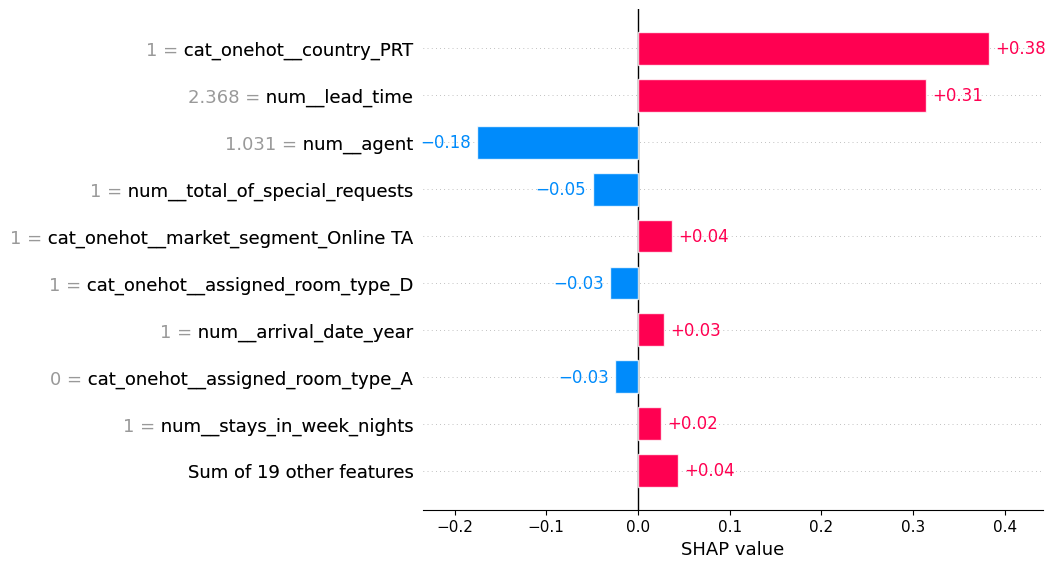

In [36]:
shap.plots.bar(shap_values_one[0])

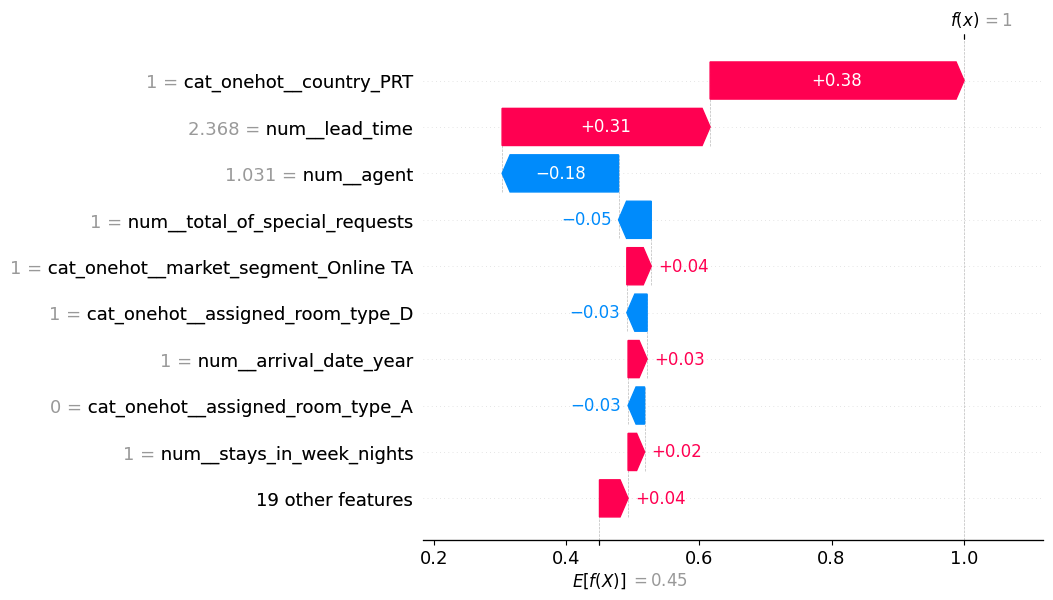

In [37]:
shap.plots.waterfall(shap_values_one[0])

In [38]:
shap.plots.force(shap_values_one[0])

In [40]:
# Let's calculate SHAP values for our whole test population
# We can use the same explainer
# This time we feed it our whole test population

# shap_values = shap_explainer(X_test_processed)

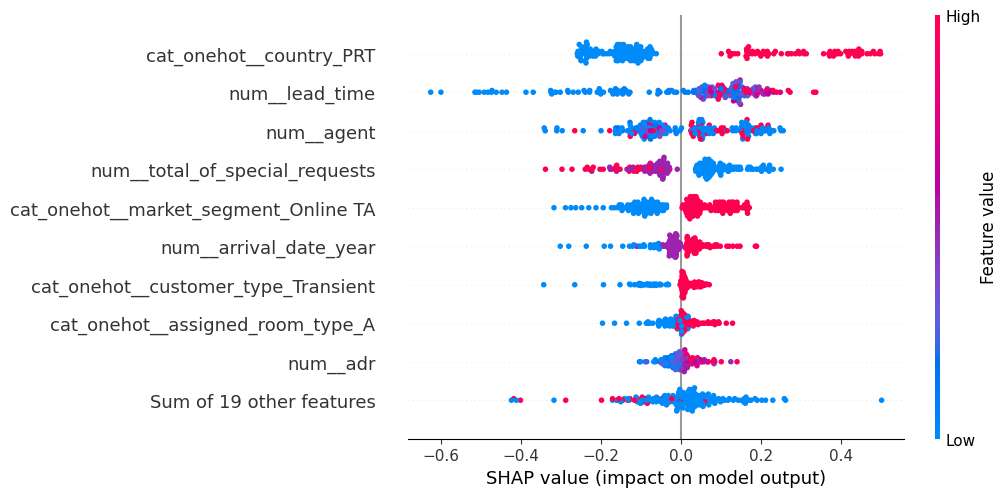

In [41]:
shap.plots.beeswarm(shap_values)